# Avance 4. Modelos alternativos

## Proyecto Integrador - MNA

### Equipo 21

Integrantes del equipo:
- Guadalupe Esmeralda González Maldonado - A01795767
- Marco Daniel Cameros Bobadilla - A01795655
- Jesús Armando Anaya Orozco - A01795464

Nombre del dataset: DDR2019

## Introducción

Trabajamos con un dataset de imágenes de fondo de ojo etiquetadas en 5 niveles de severidad de retinopatía diabética (0 = sin DR, 1 = leve, 2 = moderada, 3 = severa, 4 = proliferativa). El problema es complicado, ya que hay mucho desbalance entre clases y las severidades adyacentes (1 vs 2, 3 vs 4) son clínicamente ambiguas.

En lugar de entrenar una red profunda de punta a punta lo cual exige mucho cómputo y datos, la idea es usar backbones preentrenados en ImageNet (DenseNet-121, EfficientNet-B1, EfficientNet-B4 y ConvNeXt-Tiny) como extractores de características. Cada imagen se convierte en un vector numérico (embedding) y un modelo de Machine Learning tabular (XGBoost, LightGBM o LinearSVC) clasifica a partir de esos vectores. Para lidiar con el desbalance y la ambigüedad, fusionamos las 5 clases originales en 3 (`0`, `1+2`, `3+4`), aplicamos augmentación de datos controlada y balanceamos el conjunto de entrenamiento.

La métrica principal es **macro-F1**, que pondera igual el rendimiento en cada clase y es más informativa que la exactitud cuando hay desbalance. También reportamos accuracy, matrices de confusión e importancia de características.

En total evaluamos 7 candidatos, cuatro variantes de XGBoost (una por backbone), dos de LightGBM (DenseNet-121 y EfficientNet-B4) y una de LinearSVC (EfficientNet-B1). El mejor se elige automáticamente por macro-F1 en validación.

Para que todo sea reproducible fijamos una semilla global y la búsqueda de hiperparámetros usa RandomizedSearchCV con `n_iter=12` y `cv=3`, lo que limita el cómputo a un máximo de 36 entrenamientos por candidato.

En el notebook, primero realizamos el setup y preprocesamiento (normalización ImageNet, CLAHE), luego balanceo y augmentación con el merge de 5 a 3, después extracción de embeddings, búsqueda de hiperparámetros para cada modelo y, para terminar, la comparación de los 7 candidatos con matrices de confusión, importancia de features y selección del mejor.

## 1) Setup del proyecto y dependencias

Aquí definimos entorno, rutas y librerías. Lo importante es que la ejecución sea consistente entre corridas para poder comparar resultados de forma justa.

Se agregan algunas instrucciones para ejecutar en el servidor de entrenamiento. Para entrenamiento local no son necesarias.

In [1]:
# !pip install -U pip
# !pip install deepspeed>=0.14.0 pydantic==2.0.0 pydantic_settings
# !pip install -U scikit-learn xgboost

Se agregaron los directorios locales para cargar los archivos en la máquina donde se ejecutó por última vez este notebook.

In [2]:
from pathlib import Path
import os
import random
import time
from collections import Counter

# Resolver la raíz del proyecto de forma robusta.
# Ruta local (ajustar según el entorno de ejecución).
PROJECT_ROOT = Path("/home/anaya/Development/Robomous/sam-ai")

# Ruta alternativa para ejecución en servidor Paperspace:
#PROJECT_ROOT = Path("/notebooks/sam-ai")

os.chdir(PROJECT_ROOT)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
import torch.nn as nn
from scipy.stats import randint, uniform
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import make_scorer
from sklearn.svm import LinearSVC

from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ConvNeXt_Tiny_Weights, DenseNet121_Weights, EfficientNet_B1_Weights, EfficientNet_B4_Weights
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode
from tqdm.auto import tqdm
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sam_ml.datasets import DDR2019Dataset
from sam_ml.preprocessing.filters import apply_clahe_bgr

In [4]:
# Fijar semillas para reproducibilidad.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Fijar semillas para CUDA cuando esté disponible.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Habilitar determinismo en CUDA.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Directorios de datos.
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "ddr2019_320"
LABELS_CSV = DATA_DIR / "labels.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR (baseline): {DATA_DIR}")
print(f"labels.csv existe: {LABELS_CSV.exists()}")


PROJECT_ROOT: /home/anaya/Development/Robomous/sam-ai
DATA_DIR (baseline): /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019_320
labels.csv existe: True


In [5]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.30


In [6]:
# Cargar dataset base (una imagen por muestra) y validar contrato de salida.
# Se confirma shape, rango y tipo de label para detectar problemas de carga tempranamente.
base_dataset_train = DDR2019Dataset(
    data_dir=DATA_DIR,
    split="train",
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    transform=transforms.ToTensor(),
    random_state=SEED,
)

base_dataset_all = DDR2019Dataset(
    data_dir=DATA_DIR,
    split="all",
    transform=transforms.ToTensor(),
    random_state=SEED,
)

image_sample, label_sample = base_dataset_train[0]

print(f"Muestras train: {len(base_dataset_train)}")
print(f"Muestras all: {len(base_dataset_all)}")
print(f"Shape imagen: {tuple(image_sample.shape)}")
print(f"Label de ejemplo: {label_sample}")


Muestras train: 8764
Muestras all: 12522
Shape imagen: (3, 320, 320)
Label de ejemplo: 0


### Verificación de carga del dataset

Cargamos dos instancias de `DDR2019Dataset`: una con `split="train"` (75 % de los datos, la que usaremos para balanceo, augmentación y extracción de features) y otra con `split="all"`, dataset completo, útil para inspección general.

`DATA_DIR` apunta a `ddr2019_320`, que contiene las imágenes redimensionadas a 380×380 píxeles y un archivo `labels.csv` con las 5 etiquetas originales (0–4). Lo que esperamos al cargar es un tensor RGB en `[0, 1]` con shape `(3, 380, 380)`.

Validamos shape y label como "sanity check" rápido. En este punto el dataset todavía tiene las 5 clases originales; la fusión a 3 se hace más adelante.

## 2) Configuración de preprocesamiento para el baseline

Para el baseline usamos la normalización que espera el modelo preentrenado. `DenseNet121_Weights.DEFAULT` provee los pesos y, a través de `weights.transforms()`, nos da los valores de `mean` y `std` por canal RGB que se usaron al entrenar en ImageNet.

Normalizar con estas estadísticas no mejora el contraste de la imagen, lo que hace es alinear la distribución de píxeles con la que el backbone espera, para que los features extraídos no se degraden. También mantenemos el tamaño de entrada original de la red para que el comportamiento sea estable.

In [7]:
# Obtener pesos preentrenados y sus estadísticas de normalización para el baseline.
densenet_weights = DenseNet121_Weights.DEFAULT
densenet_preset = densenet_weights.transforms()

# mean/std por canal RGB extraídos del preset de ImageNet.
densenet_norm_mean = torch.tensor(densenet_preset.mean, dtype=torch.float32)
densenet_norm_std = torch.tensor(densenet_preset.std, dtype=torch.float32)

print("Normalización del baseline (DenseNet-121):")
print(f"  input_size esperado: {densenet_preset.crop_size[0]} x {densenet_preset.crop_size[0]}")
print(f"  mean: {densenet_norm_mean.tolist()}")
print(f"  std: {densenet_norm_std.tolist()}")


Normalización del baseline (DenseNet-121):
  input_size esperado: 224 x 224
  mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
  std: [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]


## 3) Transformaciones de normalización del baseline

Aquí definimos las funciones que preparan cada imagen para que el backbone la "vea" en condiciones similares a su preentrenamiento.

Las tres funciones son `normalize_with_stats_torch` (normalización canal a canal), `denormalize_with_stats_torch` (para poder visualizar imágenes de vuelta) y `preprocess_image_for_densenet` (pipeline completo de preprocesamiento para el baseline).

In [8]:
def normalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Normalizar tensor RGB canal a canal con media y desviación estándar.

    Parámetros
    ----------
    x : torch.Tensor — imagen con shape (3, H, W) en [0, 1].
    mean, std : torch.Tensor — estadísticas por canal (shape (3,)).

    Retorna
    -------
    torch.Tensor normalizado con la misma shape.
    """
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype).clamp_min(1e-8)
    return (x - m) / s


def denormalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Revertir la normalización para recuperar valores en [0, 1] (útil para visualización).

    Parámetros
    ----------
    x : torch.Tensor — imagen normalizada (3, H, W).
    mean, std : torch.Tensor — las mismas estadísticas usadas en la normalización.
    """
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype)
    return x * s + m


def preprocess_image_for_densenet(x: torch.Tensor) -> torch.Tensor:
    """Pipeline completo de preprocesamiento para el baseline DenseNet-121.

    Clampea a [0, 1] y normaliza con las estadísticas de ImageNet del preset.
    """
    x = x.float().clamp(0.0, 1.0)
    return normalize_with_stats_torch(x, densenet_norm_mean, densenet_norm_std)


In [9]:
def compute_eval_metrics(y_true, y_pred) -> dict:
    """Calcular métricas de evaluación: accuracy, precision, recall y F1 (macro).

    Parámetros
    ----------
    y_true : array-like — etiquetas reales.
    y_pred : array-like — predicciones del modelo.

    Retorna
    -------
    dict con val_accuracy, val_precision_macro, val_recall_macro y val_f1_macro.
    """
    return {
        "val_accuracy": float(accuracy_score(y_true, y_pred)),
        "val_precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "val_recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "val_f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

## 4) Balanceo de clases

En retinopatía diabética hay un desbalance importante entre clases, y eso impacta directamente la calidad del aprendizaje. Si se entrena sin control, el modelo tiende a optimizar para las clases frecuentes y degrada el recall en las menos representadas.

Lo que hacemos aquí es: primero fusionamos 5 clases en 3 (`0`, `1+2`, `3+4`) para reducir ambigüedad entre severidades adyacentes, luego construimos un set de entrenamiento balanceado real usando augmentación controlada (original + hflip + vflip + rotación) solo para la nueva clase 2, la cual tiene muy pocos ejemplos en comparación con las otras dos.

Lo manejamos así porque evitamos sesgo de frecuencia, es decir, que una clase domine la función objetivo, y evitamos sobre-augmentación sin criterio (que puede volver a desbalancear) y mantenemos el cómputo factible con los 4 modos de augmentación disponibles.

Esto conecta directamente con la elección de macro-F1 y macro-recall como métricas prioritarias. En escenarios desbalanceados, la accuracy puede verse alta y aun así ocultar mal desempeño en clases menos frecuentes. Balancear mejora cobertura por clase y estabilidad del entrenamiento, aunque incrementa el costo de cómputo por el número de muestras transformadas.

In [10]:
train_rows = base_dataset_train._rows.reset_index(drop=True).copy()

class_counts = train_rows["label"].value_counts().sort_index()
mean_count = class_counts.mean()
minority_threshold = mean_count * 0.5
minority_classes = set(class_counts[class_counts < minority_threshold].index.tolist())

AUGMENTATION_MULTIPLIER = 4
MAJORITY_CAP = 3500

augmentation_targets: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_minority = int(label) in minority_classes
    target_count = int(count) * AUGMENTATION_MULTIPLIER if is_minority else int(count)
    augmentation_targets[int(label)] = {
        "current_count": int(count),
        "target_count": int(target_count),
        "multiplier": AUGMENTATION_MULTIPLIER if is_minority else 1,
        "is_minority": is_minority,
    }

downsampling_ratios: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_majority = float(count) > float(mean_count)
    if is_majority and int(count) > MAJORITY_CAP:
        new_count = MAJORITY_CAP
        reduction_pct = (1.0 - (new_count / int(count))) * 100.0
    else:
        new_count = int(count)
        reduction_pct = 0.0
    downsampling_ratios[int(label)] = {
        "current_count": int(count),
        "new_count": int(new_count),
        "reduction_pct": float(reduction_pct),
        "is_downsampled": bool(is_majority and int(count) > MAJORITY_CAP),
    }

final_counts: dict[int, int] = {}
for label in sorted(class_counts.index.tolist()):
    if int(label) in minority_classes:
        final_counts[int(label)] = int(augmentation_targets[int(label)]["target_count"])
    else:
        final_counts[int(label)] = int(downsampling_ratios[int(label)]["new_count"])

original_imbalance_ratio = float(class_counts.max() / class_counts.min())
final_counts_series = pd.Series(final_counts).sort_index()
final_imbalance_ratio = float(final_counts_series.max() / final_counts_series.min())

print("Resumen de balanceo (baseline):")
print(f"  class_counts: {class_counts.to_dict()}")
print(f"  mean_count: {mean_count:.2f}")
print(f"  minority_threshold (50% mean): {minority_threshold:.2f}")
print(f"  minority_classes: {sorted(list(minority_classes))}")
print(f"  AUGMENTATION_MULTIPLIER: {AUGMENTATION_MULTIPLIER}")
print(f"  MAJORITY_CAP: {MAJORITY_CAP}")
print(f"  ratio original: {original_imbalance_ratio:.2f}:1")
print(f"  ratio final: {final_imbalance_ratio:.2f}:1")


Resumen de balanceo (baseline):
  class_counts: {0: 4386, 1: 441, 2: 3133, 3: 165, 4: 639}
  mean_count: 1752.80
  minority_threshold (50% mean): 876.40
  minority_classes: [1, 3, 4]
  AUGMENTATION_MULTIPLIER: 4
  MAJORITY_CAP: 3500
  ratio original: 26.58:1
  ratio final: 5.30:1


## 5) Utilidades de balanceo y augmentación

Estas utilidades concentran la lógica de muestreo por clase y de augmentación reproducible. La idea es mantener reglas consistentes para aumentar la exposición de clases minoritarias y reducir la dominancia de las mayoritarias.

`_sample_indices_per_class` selecciona índices aplicando downsampling a clases que superen `MAJORITY_CAP`, para que el entrenamiento no quede dominado por una sola clase. `_build_augmented_sample_list` construye la lista final de muestras como tuplas `(base_index, aug_id)`, donde `aug_id` indica la transformación (0 = original, 1 = hflip, 2 = vflip, 3 = rotación aleatoria); solo las clases minoritarias reciben las 4 variantes. `_draw_rotation_angles` genera ángulos reproducibles en [10°, 15°] con signo aleatorio.

Todo está controlado por `SEED` para reproducibilidad total. La augmentación solo se aplica en entrenamiento y las transformaciones son razonables para imágenes de fondo de ojo, donde la orientación no define la patología.

In [11]:
def _sample_indices_per_class(
    rows: pd.DataFrame,
    majority_cap: int,
    seed: int,
) -> list[int]:
    """Seleccionar índices de entrenamiento con downsampling en clases mayoritarias.

    Parámetros
    ----------
    rows : pd.DataFrame — filas del dataset con columna 'label'.
    majority_cap : int — máximo de muestras permitido por clase mayoritaria.
    seed : int — semilla para reproducibilidad del muestreo.

    Retorna
    -------
    list[int] — índices seleccionados (sin augmentación aún).
    """
    rng = np.random.default_rng(seed)
    selected: list[int] = []

    counts = rows["label"].value_counts().sort_index()
    mean_count_local = counts.mean()

    for label in sorted(counts.index.tolist()):
        cls_rows = rows[rows["label"] == label]
        cls_indices = cls_rows.index.to_numpy()
        is_majority = counts[label] > mean_count_local

        if is_majority and len(cls_indices) > majority_cap:
            chosen = rng.choice(cls_indices, size=majority_cap, replace=False)
            selected.extend(chosen.tolist())
        else:
            selected.extend(cls_indices.tolist())

    return selected


def _build_augmented_sample_list(
    rows: pd.DataFrame,
    selected_indices: list[int],
    minority_set: set[int],
) -> list[tuple[int, int]]:
    """Construir lista de muestras (base_index, aug_id) expandiendo clases minoritarias.

    Para cada índice seleccionado:
    - Si pertenece a una clase minoritaria → genera 4 tuplas (aug_id 0-3).
    - Si no → genera 1 tupla (aug_id 0, solo original).

    aug_id: 0=original, 1=hflip, 2=vflip, 3=rotación aleatoria.
    """
    samples: list[tuple[int, int]] = []
    for idx in selected_indices:
        label = int(rows.loc[idx, "label"])
        if label in minority_set:
            # 0 = original, 1 = hflip, 2 = vflip, 3 = rot
            for aug_id in (0, 1, 2, 3):
                samples.append((int(idx), int(aug_id)))
        else:
            samples.append((int(idx), 0))
    return samples


def _draw_rotation_angles(rng: np.random.Generator) -> tuple[float, float]:
    """Generar dos ángulos de rotación distintos con magnitud en [10°, 15°] y signo aleatorio."""

    def _one_angle() -> float:
        mag = float(rng.uniform(10.0, 15.0))
        sign = -1.0 if rng.random() < 0.5 else 1.0
        return sign * mag

    angle1 = _one_angle()
    angle2 = _one_angle()
    while abs(angle2 - angle1) < 1e-6:
        angle2 = _one_angle()
    return angle1, angle2



## 6) Verificación inicial del pipeline

Este bloque valida la integridad básica del flujo antes de entrenar. Formato y dimensiones de tensores, etiquetas en rango válido, consistencia entre tamaño del batch y contenido. Es una verificación rápida para detectar errores de datos temprano y evitar diagnósticos confusos durante el entrenamiento.

In [12]:
# Verificación rápida: cargar un mini-batch y comprobar shapes y rangos.
batch_size = 8
baseline_loader = DataLoader(
    base_dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

images_batch, labels_batch = next(iter(baseline_loader))

print("Verificación rápida:")
print(f"  images_batch shape: {tuple(images_batch.shape)}")
print(f"  labels_batch shape: {tuple(labels_batch.shape)}")
print(f"  rango imágenes: [{float(images_batch.min()):.3f}, {float(images_batch.max()):.3f}]")


Verificación rápida:
  images_batch shape: (8, 3, 320, 320)
  labels_batch shape: (8,)
  rango imágenes: [0.000, 1.000]


=== Resumen de pipeline ===
DATA_DIR: /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019_320
Split train base: 8764
Split all base: 12522
images_batch shape: (8, 3, 320, 320)
labels_batch shape: (8,)
Distribución original (train): {0: 4386, 1: 441, 2: 3133, 3: 165, 4: 639}
Distribución final objetivo: {0: 3500, 1: 1764, 2: 3133, 3: 660, 4: 2556}
Ratio original: 26.58:1
Ratio final: 5.30:1


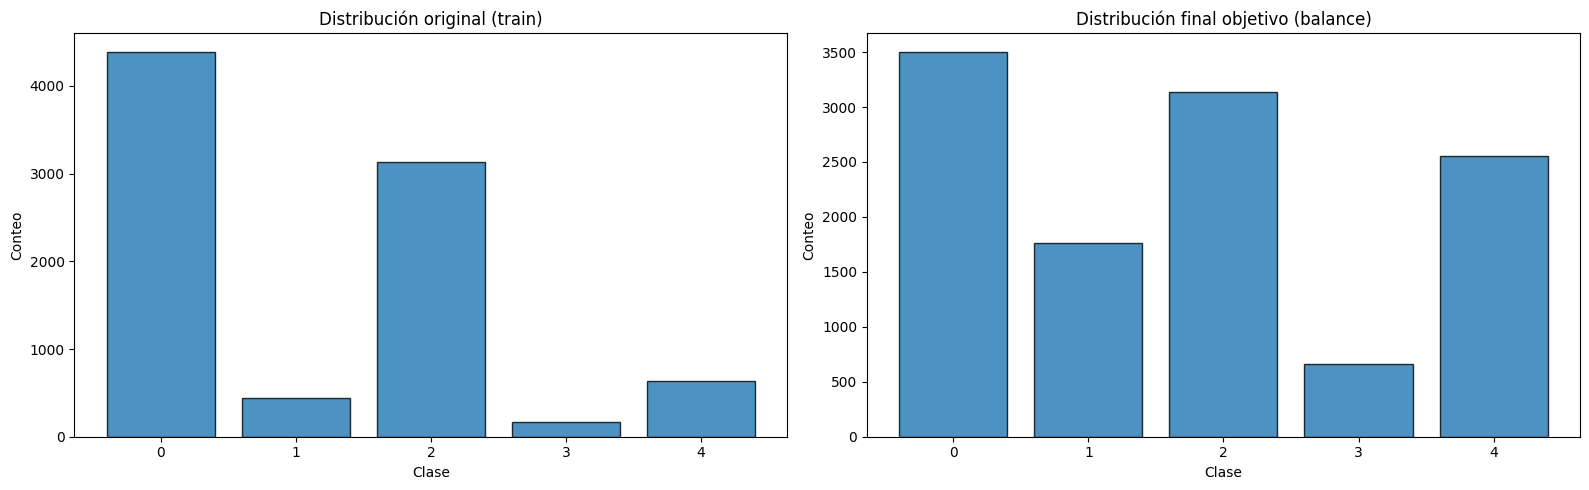

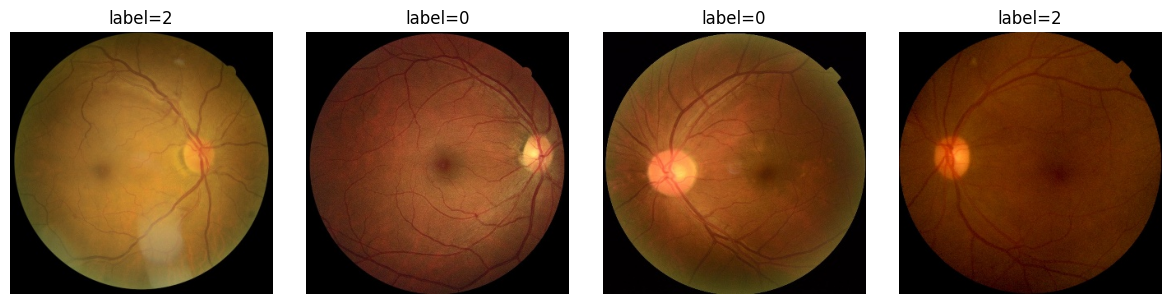

In [13]:
# Resumen consolidado: rutas, splits, distribuciones y visualización de muestras.
print("=== Resumen de pipeline ===")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Split train base: {len(base_dataset_train)}")
print(f"Split all base: {len(base_dataset_all)}")
print(f"images_batch shape: {tuple(images_batch.shape)}")
print(f"labels_batch shape: {tuple(labels_batch.shape)}")
print(f"Distribución original (train): {class_counts.to_dict()}")
print(f"Distribución final objetivo: {final_counts_series.to_dict()}")
print(f"Ratio original: {original_imbalance_ratio:.2f}:1")
print(f"Ratio final: {final_imbalance_ratio:.2f}:1")

# Graficar distribución original vs final objetivo.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

classes_sorted = sorted(class_counts.index.tolist())
x = np.arange(len(classes_sorted))
orig_values = [int(class_counts.loc[c]) for c in classes_sorted]
final_values = [int(final_counts_series.loc[c]) for c in classes_sorted]

axes[0].bar(x, orig_values, edgecolor="black", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes_sorted)
axes[0].set_title("Distribución original (train)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Conteo")

axes[1].bar(x, final_values, edgecolor="black", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes_sorted)
axes[1].set_title("Distribución final objetivo (balance)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Conteo")

plt.tight_layout()
plt.show()

# Mostrar muestras del batch de la baseline.
n_show = min(4, images_batch.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = np.array([axes])

for i in range(n_show):
    image_vis = images_batch[i].detach().cpu().clamp(0.0, 1.0)
    axes[i].imshow(np.transpose(image_vis.numpy(), (1, 2, 0)))
    axes[i].set_title(f"label={int(labels_batch[i])}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Justificación de la fusión de 5 clases a 3 clases

Después de aplicar aumento de datos en las cinco clases originales, vimos que algunas categorías siguen muy desbalanceadas y que las fronteras entre severidades adyacentes (1 vs 2, 3 vs 4) son especialmente ruidosas. Intentamos entrenar respetando las 5 clases, pero los resultados no fueron buenos, el modelo confundía sistemáticamente los pares adyacentes.

Por eso decidimos fusionar clases 1 + 2 en una sola (retinopatía leve-moderada) y clases 3 + 4 en otra (retinopatía severa-proliferativa), manteniendo la clase 0 (sin retinopatía). Esto reduce la ambigüedad clínica entre grados que incluso los oftalmólogos confunden con frecuencia, aumenta las muestras por clase resultante y mantiene la distinción clínicamente relevante. Sin DR, DR no severa y DR severa.

Los resultados se reportan en el espacio de 3 clases, así que no son directamente comparables con benchmarks de 5 clases. El merge reduce granularidad, pero mejora estabilidad y confiabilidad de las predicciones.

## 7) Baseline (DenseNet-121 + XGBoost)

Usamos este baseline en la entrega anterior, porque es una forma práctica de clasificar imágenes con costo de cómputo controlado y resultados reproducibles. DenseNet-121 preentrenado convierte cada imagen en un vector de números que resume su contenido visual, y XGBoost toma ese vector y aprende a predecir la clase. Además es rápido de entrenar y permite revisar qué señales influyen más.

### Embedding

Es el vector numérico que produce el backbone al procesar una imagen. Se toma la red preentrenada, se le quita la capa de clasificación final (el _head_) y se reemplaza por `nn.Identity()`. Al pasar una imagen, la salida es un vector (de 1024 dimensiones para DenseNet-121, por ejemplo) que codifica las características visuales aprendidas. Ese vector se usa como fila de una tabla, y sobre esa tabla el modelo tabular aprende a clasificar.

La ventaja es que el backbone ya sabe detectar patrones visuales complejos (bordes, texturas, formas) gracias a su preentrenamiento en ImageNet, y el modelo tabular solo necesita aprender la relación entre esos patrones y las clases de retinopatía.

### macro-F1

Calcula el F1-score de cada clase por separado y promedia sin ponderar por frecuencia. Todas las clases pesan igual, independientemente de cuántas muestras tengan. Es la métrica más adecuada cuando hay desbalance, porque evita que una clase mayoritaria "infle" el resultado global.

El modelo debe superar un punto de referencia trivial, predecir siempre la clase mayoritaria. Si no lo supera, probablemente el problema está en la señal de los datos o en el preprocesamiento.

### Ajuste metodológico previo al feature engineering

Antes de extraer características hacemos algunos ajustes para que el entrenamiento sea más estable e interpretable. Reducimos de 5 a 3 clases agrupando etiquetas cercanas (`0`, `1+2`, `3+4`) para disminuir la ambigüedad entre grados adyacentes. También buscamos un balance controlado entre clases, la clase 0 se limita a `MAJORITY_CAP` muestras, las clases 1 y 2 se expanden con augmentación geométrica (hflip, vflip, rotación) y se verifica la distribución final con `final_train_counts` y `final_train_proportions`.

La augmentación es geométrica simple, razonable para imágenes de retina donde la orientación no define la patología. Se aplica CLAHE de forma consistente en train y val para evitar cambios de distribución entre conjuntos.

La distribución que se muestra en esta sección corresponde al dataset final que entra al modelo, no a una etapa intermedia.

In [14]:
def _imagenet_stats_from_weights(weights_enum: object) -> tuple[list[float], list[float]]:
    weights = weights_enum.DEFAULT
    mean = list(weights.meta.get("mean", (0.485, 0.456, 0.406)))
    std = list(weights.meta.get("std", (0.229, 0.224, 0.225)))
    return mean, std


def _input_size_from_weights(weights_enum: object, default: int = 224) -> int:
    weights = weights_enum.DEFAULT
    crop_size = getattr(weights.transforms(), "crop_size", None)
    if crop_size is None:
        return int(default)

    if isinstance(crop_size, (tuple, list)):
        if len(crop_size) == 0:
            return int(default)
        return int(crop_size[0])

    return int(crop_size)


def _imagenet_stats_from_densenet() -> tuple[list[float], list[float]]:
    return _imagenet_stats_from_weights(DenseNet121_Weights)


def _imagenet_stats_from_efficientnet_b1() -> tuple[list[float], list[float]]:
    return _imagenet_stats_from_weights(EfficientNet_B1_Weights)


def _imagenet_stats_from_efficientnet_b4() -> tuple[list[float], list[float]]:
    return _imagenet_stats_from_weights(EfficientNet_B4_Weights)


def _imagenet_stats_from_convnext_tiny() -> tuple[list[float], list[float]]:
    return _imagenet_stats_from_weights(ConvNeXt_Tiny_Weights)


def _to_gray(x: torch.Tensor) -> torch.Tensor:
    """Convertir RGB a escala de grises (tensor CHW en [0,1])."""
    r, g, b = x[0], x[1], x[2]
    return (0.2989 * r + 0.5870 * g + 0.1140 * b).clamp(0.0, 1.0)


def _global_features(x: torch.Tensor, hist_bins: int = 16) -> torch.Tensor:
    """Calcular features globales: media/desviación por canal RGB + histograma en escala de grises.

    Se concatenan como vector auxiliar al embedding del backbone.
    """
    ch_mean = x.mean(dim=(1, 2))
    ch_std = x.std(dim=(1, 2), unbiased=False)

    gray = _to_gray(x)
    hist = torch.histc(gray, bins=int(hist_bins), min=0.0, max=1.0)
    hist = hist / (hist.sum().clamp_min(1.0))

    return torch.cat([ch_mean, ch_std, hist], dim=0).float()


def _apply_geometry(
    image: torch.Tensor,
    aug_id: int,
    idx: int,
    seed: int,
) -> torch.Tensor:
    """Aplicar augmentación geométrica simple, reproducible por índice y semilla.

    aug_id: 0=original, 1=hflip, 2=vflip, 3=rotación aleatoria [10°-15°].
    """
    if int(aug_id) == 0:
        return image
    if int(aug_id) == 1:
        return TF.hflip(image)
    if int(aug_id) == 2:
        return TF.vflip(image)

    rng = np.random.default_rng(int(seed) + int(idx))
    mag = float(rng.uniform(10.0, 15.0))
    sign = -1.0 if rng.random() < 0.5 else 1.0
    angle = sign * mag

    return TF.rotate(
        image,
        angle=float(angle),
        interpolation=InterpolationMode.BILINEAR,
        fill=0.0,
    )


LABEL_MAP_5_TO_3: dict[int, int] = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}


class MappedLabelDataset(Dataset):
    """Envolver un dataset base y remapear sus etiquetas preservando soporte de _rows."""

    def __init__(self, base_dataset: DDR2019Dataset, label_map: dict[int, int]) -> None:
        self.base_dataset = base_dataset
        self.label_map = dict(label_map)
        self._rows = self.base_dataset._rows.copy()
        self._rows["label"] = self._rows["label"].map(self.label_map).astype(int)

    def __len__(self) -> int:
        return len(self.base_dataset)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        image, label = self.base_dataset[int(idx)]
        return image, int(self.label_map[int(label)])


class ClahePILTransform:
    """Aplicar CLAHE en espacio BGR y devolver imagen PIL en RGB."""

    def __call__(self, image: Image.Image) -> Image.Image:
        rgb = np.asarray(image.convert("RGB"), dtype=np.uint8)
        bgr = np.ascontiguousarray(rgb[..., ::-1])
        bgr_clahe = apply_clahe_bgr(bgr)
        rgb_clahe = np.ascontiguousarray(bgr_clahe[..., ::-1])
        return Image.fromarray(rgb_clahe)


class BaselineSingleFeatureDataset(Dataset):
    """Dataset baseline: imagen preprocesada para el backbone + features globales auxiliares.

    Cada muestra devuelve un diccionario con:
    - 'image': tensor normalizado listo para el backbone.
    - 'extra': vector de features globales (estadísticas de canal + histograma).
    - 'label': etiqueta (ya mapeada si corresponde).
    """

    def __init__(
        self,
        base_dataset: "DDR2019Dataset",
        samples: list[tuple[int, int]],
        seed: int,
        image_size: int = 224,
        hist_bins: int = 16,
        mean: list[float] | None = None,
        std: list[float] | None = None,
    ) -> None:
        self.base_dataset = base_dataset
        self.samples = list(samples)
        self.seed = int(seed)
        self.image_size = int(image_size)
        self.hist_bins = int(hist_bins)

        densenet_mean, densenet_std = _imagenet_stats_from_densenet()
        self.mean = list(densenet_mean if mean is None else mean)
        self.std = list(densenet_std if std is None else std)

    def __len__(self) -> int:
        return len(self.samples)

    def _prep_for_backbone(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = TF.resize(
            x,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )
        x = x.float().clamp(0.0, 1.0)

        extra = _global_features(x, hist_bins=self.hist_bins)
        x_norm = TF.normalize(x, mean=self.mean, std=self.std)
        return x_norm, extra

    def __getitem__(self, item_idx: int) -> dict[str, torch.Tensor]:
        base_index, aug_id = self.samples[int(item_idx)]
        image, label = self.base_dataset[int(base_index)]
        image = image.float().clamp(0.0, 1.0)

        image_aug = _apply_geometry(
            image,
            aug_id=int(aug_id),
            idx=int(base_index),
            seed=self.seed,
        )

        image_in, extra = self._prep_for_backbone(image_aug)

        return {
            "image": image_in,
            "extra": extra,
            "label": torch.tensor(int(label), dtype=torch.long),
        }


# Constructores de backbones como extractores de características (sin head de clasificación).
def build_densenet121_feature_extractor() -> nn.Module:
    """Construir DenseNet-121 preentrenado como extractor de features: salida (B, 1024)."""
    model = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Identity()

    for p in model.parameters():
        p.requires_grad = False

    return model


def build_efficientnet_b1_feature_extractor() -> nn.Module:
    """Construir EfficientNet-B1 preentrenado como extractor de features: salida (B, 1280)."""
    model = models.efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
    model.classifier = nn.Identity()

    for p in model.parameters():
        p.requires_grad = False

    return model


def build_efficientnet_b4_feature_extractor() -> nn.Module:
    """Construir EfficientNet-B4 preentrenado como extractor de features: salida (B, 1792)."""
    model = models.efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
    model.classifier = nn.Identity()

    for p in model.parameters():
        p.requires_grad = False

    return model


def build_convnext_tiny_feature_extractor() -> nn.Module:
    """Construir ConvNeXt-Tiny preentrenado como extractor de features: salida (B, 768)."""
    model = models.convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    model.classifier[2] = nn.Identity()

    for p in model.parameters():
        p.requires_grad = False

    return model


def _forward_backbone_features(feature_model: nn.Module, image: torch.Tensor) -> torch.Tensor:
    out = feature_model(image)
    if isinstance(out, torch.Tensor):
        return out
    if isinstance(out, (tuple, list)):
        out0 = out[0]
        if not isinstance(out0, torch.Tensor):
            raise TypeError("Backbone output tuple/list does not contain tensor features.")
        return out0
    if isinstance(out, dict):
        for key in ("features", "logits", "out"):
            if key in out and isinstance(out[key], torch.Tensor):
                return out[key]
    raise TypeError(f"Unsupported backbone output type: {type(out)}")


@torch.no_grad()
def extract_backbone_features(
    feature_model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    desc: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Extraer features concatenadas (embedding del backbone + features globales auxiliares).

    Recorre el DataLoader completo en modo evaluación, concatena todos los vectores
    y devuelve matrices numpy (X, y) listas para entrenar un modelo tabular.
    """
    feature_model = feature_model.to(device)
    feature_model.eval()

    feats: list[np.ndarray] = []
    labels: list[np.ndarray] = []

    for batch in tqdm(loader, desc=desc, total=len(loader)):
        image = batch["image"].to(device, non_blocking=True)
        extra = batch["extra"].to(device, non_blocking=True)
        y = batch["label"].detach().cpu().numpy()

        f = _forward_backbone_features(feature_model, image)
        f = torch.cat([f, extra], dim=1)

        feats.append(f.detach().cpu().numpy())
        labels.append(y)

    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labels, axis=0)

    print("Dimensión de la matriz de features:", X.shape)
    return X, y


In [15]:
# ---------------------------------------------------------------------------
# Funciones reutilizables para fine-tuning de ConvNeXt-Tiny con búsqueda HP
# ---------------------------------------------------------------------------

def sample_hparams_random(
    n_trials: int,
    seed: int,
    head_lr_low: float = 1e-4,
    head_lr_high: float = 2e-3,
    backbone_lr_low: float = 5e-6,
    backbone_lr_high: float = 2e-4,
    wd_low: float = 1e-5,
    wd_high: float = 5e-3,
    head_dropout_options: list[float] | None = None,
    unfreeze_blocks_options: list[int] | None = None,
) -> list[dict]:
    """Muestrear *n_trials* configuraciones para fine-tuning de un modelo preentrenado.

    Se utilizan tasas de aprendizaje diferenciadas para la cabeza (head) y el
    backbone, ya que la cabeza se entrena desde cero mientras que el backbone
    solo requiere ajustes finos sobre pesos preentrenados.
    """
    if head_dropout_options is None:
        head_dropout_options = [0.3, 0.4, 0.5]
    if unfreeze_blocks_options is None:
        unfreeze_blocks_options = [2, 3]

    rng = np.random.default_rng(seed)
    trials = []
    for _ in range(n_trials):
        head_lr = float(np.exp(rng.uniform(np.log(head_lr_low), np.log(head_lr_high))))
        backbone_lr = float(np.exp(rng.uniform(np.log(backbone_lr_low), np.log(backbone_lr_high))))
        wd = float(np.exp(rng.uniform(np.log(wd_low), np.log(wd_high))))
        dropout = float(rng.choice(head_dropout_options))
        unfreeze = int(rng.choice(unfreeze_blocks_options))
        trials.append({
            "head_lr": head_lr,
            "backbone_lr": backbone_lr,
            "weight_decay": wd,
            "head_dropout": dropout,
            "unfreeze_blocks": unfreeze,
        })
    return trials


def make_stratified_subset(
    samples: list[tuple[int, int]],
    labels: np.ndarray,
    fraction: float,
    seed: int,
) -> tuple[list[tuple[int, int]], np.ndarray]:
    """Subconjunto estratificado de *samples* usando StratifiedShuffleSplit."""
    sss = StratifiedShuffleSplit(n_splits=1, train_size=fraction, random_state=seed)
    subset_idx, _ = next(sss.split(np.zeros(len(labels)), labels))
    subset_samples = [samples[i] for i in subset_idx]
    subset_labels = labels[subset_idx]
    return subset_samples, subset_labels


def build_convnext_tiny_for_finetuning(
    num_classes: int = 3,
    head_dropout: float = 0.0,
    unfreeze_blocks: int = 0,
) -> nn.Module:
    """ConvNeXt-Tiny preentrenado con cabeza de clasificación entrenable.

    Parámetros para fine-tuning controlado de modelos preentrenados:
    - head_dropout: regularización en la cabeza para evitar sobreajuste.
    - unfreeze_blocks: cantidad de bloques superiores del backbone a descongelar.
      Si es 0, se descongelan TODOS los parámetros (fine-tuning completo).
    """
    model = models.convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

    if unfreeze_blocks > 0:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.features[-unfreeze_blocks:].parameters():
            p.requires_grad = True

    in_features = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],       # LayerNorm
        model.classifier[1],       # Flatten
        nn.Dropout(p=head_dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


def _run_one_ft_epoch(model, loader, optimizer, criterion, device, is_train: bool,
                      epoch_desc: str = "", scheduler=None):
    """Ejecutar una época de fine-tuning (train o eval)."""
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []
    ctx = torch.no_grad() if not is_train else torch.enable_grad()

    phase = "Train" if is_train else "Val"
    bar_desc = f"{epoch_desc} {phase}" if epoch_desc else phase

    with ctx:
        for batch in tqdm(loader, desc=bar_desc, leave=False):
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    if is_train and scheduler is not None:
        scheduler.step()

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(all_labels)
    macro_f1 = float(f1_score(all_labels, all_preds, average="macro", zero_division=0))
    return avg_loss, macro_f1


def kfold_finetune_eval(
    trial: dict,
    subset_samples: list[tuple[int, int]],
    subset_labels: np.ndarray,
    base_dataset,
    k: int,
    epochs: int,
    seed: int,
    device: torch.device,
    num_classes: int = 3,
    batch_size: int = 32,
    image_size: int = 224,
    hist_bins: int = 16,
    label_smoothing: float = 0.0,
    patience: int = 0,
    scheduler_eta_min: float = 1e-6,
) -> dict:
    """Evaluar un trial con K-Fold CV sobre el subconjunto estratificado.

    Implementa prácticas estándar para fine-tuning de modelos preentrenados:
    - LR diferenciado (head vs backbone).
    - Weighted CrossEntropyLoss + label smoothing.
    - CosineAnnealingLR.
    - Early stopping opcional por fold.
    """
    head_lr = trial["head_lr"]
    backbone_lr = trial["backbone_lr"]
    wd = trial["weight_decay"]
    head_dropout = trial["head_dropout"]
    unfreeze_blocks = trial["unfreeze_blocks"]
    convnext_mean, convnext_std = _imagenet_stats_from_convnext_tiny()

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    fold_scores: list[float] = []
    t0 = time.perf_counter()

    folds_iter = list(enumerate(skf.split(np.zeros(len(subset_labels)), subset_labels)))
    for fold_idx, (train_idx, val_idx) in tqdm(folds_iter, desc=f"Folds (hlr={head_lr:.1e})", leave=False):
        fold_train_samples = [subset_samples[i] for i in train_idx]
        fold_val_samples = [subset_samples[i] for i in val_idx]
        fold_train_labels = subset_labels[train_idx]

        fold_train_ds = BaselineSingleFeatureDataset(
            base_dataset=base_dataset,
            samples=fold_train_samples,
            seed=seed,
            image_size=image_size,
            hist_bins=hist_bins,
            mean=convnext_mean,
            std=convnext_std,
        )
        fold_val_ds = BaselineSingleFeatureDataset(
            base_dataset=base_dataset,
            samples=fold_val_samples,
            seed=seed,
            image_size=image_size,
            hist_bins=hist_bins,
            mean=convnext_mean,
            std=convnext_std,
        )
        fold_train_loader = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
        fold_val_loader = DataLoader(fold_val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

        torch.manual_seed(seed + fold_idx)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed + fold_idx)

        model = build_convnext_tiny_for_finetuning(
            num_classes, head_dropout=head_dropout, unfreeze_blocks=unfreeze_blocks,
        ).to(device)

        head_params = list(model.classifier.parameters())
        head_param_ids = {id(p) for p in head_params}
        backbone_params = [p for p in model.parameters() if p.requires_grad and id(p) not in head_param_ids]

        optimizer = torch.optim.AdamW([
            {"params": head_params, "lr": head_lr},
            {"params": backbone_params, "lr": backbone_lr},
        ], weight_decay=wd)

        class_weights = compute_class_weights(fold_train_labels, num_classes).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=scheduler_eta_min)

        best_val_f1 = -1.0
        epochs_no_improve = 0

        for epoch in tqdm(range(epochs), desc=f"Fold {fold_idx+1} épocas", leave=False):
            _run_one_ft_epoch(
                model, fold_train_loader, optimizer, criterion, device,
                is_train=True, epoch_desc=f"F{fold_idx+1} E{epoch+1}",
                scheduler=scheduler,
            )
            if patience > 0:
                _, ef1 = _run_one_ft_epoch(
                    model, fold_val_loader, None, criterion, device,
                    is_train=False, epoch_desc=f"F{fold_idx+1} ES",
                )
                if ef1 > best_val_f1:
                    best_val_f1 = ef1
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        break

        _, val_f1 = _run_one_ft_epoch(
            model, fold_val_loader, None, criterion, device,
            is_train=False, epoch_desc=f"F{fold_idx+1}",
        )
        fold_scores.append(val_f1)

        del model, optimizer, scheduler
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    elapsed = time.perf_counter() - t0
    return {
        "head_lr": head_lr,
        "backbone_lr": backbone_lr,
        "weight_decay": wd,
        "head_dropout": head_dropout,
        "unfreeze_blocks": unfreeze_blocks,
        "fold_scores": fold_scores,
        "mean_f1": float(np.mean(fold_scores)),
        "std_f1": float(np.std(fold_scores)),
        "elapsed_s": elapsed,
    }


def finetune_full(
    head_lr: float,
    backbone_lr: float,
    wd: float,
    train_samples: list[tuple[int, int]],
    train_labels: np.ndarray,
    base_dataset,
    epochs: int,
    seed: int,
    device: torch.device,
    num_classes: int = 3,
    batch_size: int = 32,
    image_size: int = 224,
    hist_bins: int = 16,
    head_dropout: float = 0.0,
    unfreeze_blocks: int = 0,
    label_smoothing: float = 0.0,
    scheduler_eta_min: float = 1e-6,
) -> nn.Module:
    """Fine-tunear ConvNeXt-Tiny en el conjunto COMPLETO de entrenamiento.

    Usa LR diferenciado, weighted CE, CosineAnnealingLR y label smoothing
    según las mejores prácticas para fine-tuning de modelos preentrenados.
    """
    convnext_mean, convnext_std = _imagenet_stats_from_convnext_tiny()
    train_ds = BaselineSingleFeatureDataset(
        base_dataset=base_dataset,
        samples=train_samples,
        seed=seed,
        image_size=image_size,
        hist_bins=hist_bins,
        mean=convnext_mean,
        std=convnext_std,
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = build_convnext_tiny_for_finetuning(
        num_classes, head_dropout=head_dropout, unfreeze_blocks=unfreeze_blocks,
    ).to(device)

    head_params = list(model.classifier.parameters())
    head_param_ids = {id(p) for p in head_params}
    backbone_params = [p for p in model.parameters() if p.requires_grad and id(p) not in head_param_ids]

    optimizer = torch.optim.AdamW([
        {"params": head_params, "lr": head_lr},
        {"params": backbone_params, "lr": backbone_lr},
    ], weight_decay=wd)

    class_weights = compute_class_weights(train_labels, num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=scheduler_eta_min)

    for epoch in tqdm(range(epochs), desc="Fine-tuning final", leave=True):
        loss, f1 = _run_one_ft_epoch(
            model, train_loader, optimizer, criterion, device,
            is_train=True, epoch_desc=f"E{epoch+1}/{epochs}",
            scheduler=scheduler,
        )
        current_head_lr = optimizer.param_groups[0]["lr"]
        current_bb_lr = optimizer.param_groups[1]["lr"] if backbone_params else 0.0
        print(f"  Época {epoch + 1}/{epochs} — loss: {loss:.4f}, macro-F1: {f1:.4f}, "
              f"head_lr: {current_head_lr:.2e}, bb_lr: {current_bb_lr:.2e}")

    return model


def compute_class_weights(labels: np.ndarray, num_classes: int) -> torch.FloatTensor:
    """Pesos inversamente proporcionales a la frecuencia de cada clase.

    Estándar para datasets desbalanceados en clasificación de imágenes médicas:
    weight[c] = total / (num_classes * count[c]).
    """
    counts = np.bincount(labels.astype(int), minlength=num_classes).astype(float)
    counts = np.maximum(counts, 1.0)
    weights = float(len(labels)) / (num_classes * counts)
    return torch.FloatTensor(weights)


def convert_to_feature_extractor(model: nn.Module) -> nn.Module:
    """Convertir modelo fine-tuneado en extractor de features (sin cabeza de clasificación)."""
    model.classifier[2] = nn.Identity()
    model.classifier[3] = nn.Identity()
    for p in model.parameters():
        p.requires_grad = False
    model.eval()
    return model

In [16]:
# 1) Cargar dataset con CLAHE consistente en train y val.
# CLAHE mejora el contraste local, lo cual ayuda a resaltar estructuras retinales.
# Se aplica el mismo preprocesamiento a ambos splits para evitar cambios de distribución.
DATA_DIR_BASELINE = DATA_DIR

clahe_to_tensor = transforms.Compose([
    ClahePILTransform(),
    transforms.ToTensor(),
])

baseline_train_ds_raw = DDR2019Dataset(
    data_dir=DATA_DIR_BASELINE,
    split="train",
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    transform=clahe_to_tensor,
    random_state=SEED,
)
baseline_val_ds_raw = DDR2019Dataset(
    data_dir=DATA_DIR_BASELINE,
    split="val",
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    transform=clahe_to_tensor,
    random_state=SEED,
)

baseline_train_ds = MappedLabelDataset(baseline_train_ds_raw, LABEL_MAP_5_TO_3)
baseline_val_ds = MappedLabelDataset(baseline_val_ds_raw, LABEL_MAP_5_TO_3)

print("Dataset baseline - decisiones de datos")
print(f"  DATA_DIR_BASELINE: {DATA_DIR_BASELINE}")
print(f"  train samples: {len(baseline_train_ds)}")
print(f"  val samples  : {len(baseline_val_ds)}")
print(f"  mapeo de etiquetas usado (5-3): {LABEL_MAP_5_TO_3}")
print(f"  etiquetas presentes en train tras mapeo: {sorted(baseline_train_ds._rows['label'].unique().tolist())}")
print("  consistencia de preprocesamiento: CLAHE se aplica tanto a train como a val")

Dataset baseline - decisiones de datos
  DATA_DIR_BASELINE: /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019_320
  train samples: 8764
  val samples  : 3758
  mapeo de etiquetas usado (5-3): {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}
  etiquetas presentes en train tras mapeo: [0, 1, 2]
  consistencia de preprocesamiento: CLAHE se aplica tanto a train como a val


In [17]:
# 2) Estrategia de muestreo tras el merge 5→3 clases.
# Política por clase en entrenamiento:
# - Clase 0: se mantiene tal cual (sin augmentación).
# - Clase 1: se mantiene, pero se barajan los ejemplos para variabilidad.
# - Clase 2: se aplica augmentación ×4 (original + 3 variantes geométricas).
# Validación: solo merge de etiquetas, sin augmentación.
train_rows_baseline = baseline_train_ds._rows.reset_index(drop=True).copy()
class_counts_baseline = train_rows_baseline["label"].value_counts().sort_index()

CLASS2_AUGMENTATION_MODES = [0, 1, 2, 3]
rng = np.random.default_rng(SEED)
train_samples: list[tuple[int, int]] = []

for class_id in sorted(int(x) for x in class_counts_baseline.index.tolist()):
    class_indices = train_rows_baseline[train_rows_baseline["label"] == class_id].index.to_numpy()

    # Barajar clase 1 explícitamente para romper cualquier orden implícito.
    # Barajar clase 1 para romper cualquier orden implícito del dataset.
    if class_id == 1:
        class_indices = rng.permutation(class_indices)

    if class_id == 2:
        # ×4 solo para la clase severa fusionada (nueva clase 2).
        for aug_id in CLASS2_AUGMENTATION_MODES:
            train_samples.extend((int(idx), int(aug_id)) for idx in class_indices.tolist())
    else:
        # Clases 0 y 1: solo la imagen original.
        train_samples.extend((int(idx), 0) for idx in class_indices.tolist())

# Distribución final que efectivamente usa el modelo para entrenar.
train_counts_after_aug = (
    pd.Series([int(train_rows_baseline.loc[int(idx), "label"]) for idx, _ in train_samples])
    .value_counts()
    .sort_index()
)
train_proportions_after_aug = (train_counts_after_aug / train_counts_after_aug.sum()).sort_index()

print("Resumen de augmentación del set de entrenamiento (estrategia aplicada):")
print(f"  merged class_counts (raw train split): {class_counts_baseline.to_dict()}")
print("  clase 0: solo original")
print("  clase 1: solo original + orden barajado")
print(f"  clase 2: ×4 con modos {CLASS2_AUGMENTATION_MODES}")
print(f"  final_train_counts used by model: {train_counts_after_aug.to_dict()}")
print(
    "  final_train_proportions used by model (%): "
    + str({int(k): round(float(v) * 100.0, 2) for k, v in train_proportions_after_aug.items()})
)

# Validación mantiene distribución natural (etiquetas fusionadas, sin augmentación).
val_samples = [(int(i), 0) for i in range(len(baseline_val_ds))]

# Verificaciones rápidas de integridad.
print("Verificaciones de integridad:")
print(f"  train_samples: {len(train_samples)}")
print(f"  val_samples  : {len(val_samples)}")
print(f"  labels in train rows: {sorted(class_counts_baseline.index.astype(int).tolist())}")

check_idx = int(train_rows_baseline[train_rows_baseline["label"] == 2].index[0])
img_base, _ = baseline_train_ds[check_idx]
img_rot = _apply_geometry(img_base, aug_id=3, idx=check_idx, seed=SEED)
print(f"  augmentation changed sample (class 2, rotation): {bool(not torch.allclose(img_base, img_rot))}")

Resumen de augmentación del set de entrenamiento (estrategia aplicada):
  merged class_counts (raw train split): {0: 4386, 1: 3574, 2: 804}
  clase 0: solo original
  clase 1: solo original + orden barajado
  clase 2: ×4 con modos [0, 1, 2, 3]
  final_train_counts used by model: {0: 4386, 1: 3574, 2: 3216}
  final_train_proportions used by model (%): {0: 39.24, 1: 31.98, 2: 28.78}
Verificaciones de integridad:
  train_samples: 11176
  val_samples  : 3758
  labels in train rows: [0, 1, 2]
  augmentation changed sample (class 2, rotation): True


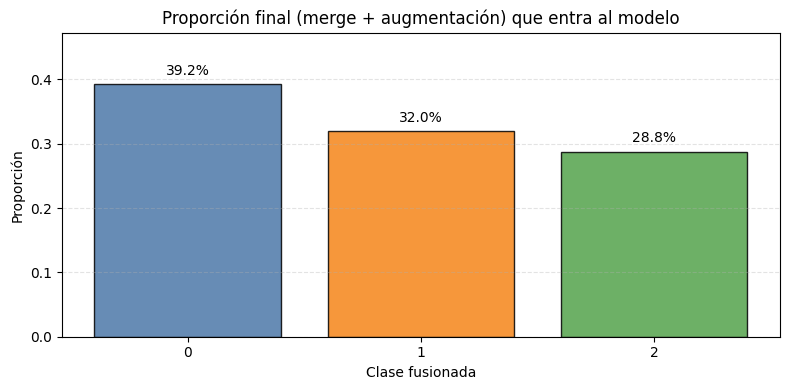

In [18]:
# Gráfica de la distribución proporcional final (después de merge + augmentación).
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    train_proportions_after_aug.index.astype(str),
    train_proportions_after_aug.values,
    color=["#4C78A8", "#F58518", "#54A24B"],
    edgecolor="black",
    alpha=0.85,
)

for bar, prop in zip(bars, train_proportions_after_aug.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{prop * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Proporción final (merge + augmentación) que entra al modelo")
ax.set_xlabel("Clase fusionada")
ax.set_ylabel("Proporción")
ax.set_ylim(0, min(1.0, float(train_proportions_after_aug.max()) + 0.08))
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [19]:
# Verificación: confirmar que train_samples y val_samples existen.
# La estrategia de muestreo/augmentación se define en la celda anterior;
# esta celda solo valida que están disponibles para las siguientes etapas.
if "train_samples" not in globals() or "val_samples" not in globals():
    raise RuntimeError(
        "No se encontraron train_samples/val_samples. Ejecuta primero la celda de estrategia de muestreo."
    )

print("Estrategia activa verificada: train_samples y val_samples ya están definidos.")
print(f"  train_samples: {len(train_samples)}")
print(f"  val_samples  : {len(val_samples)}")

Estrategia activa verificada: train_samples y val_samples ya están definidos.
  train_samples: 11176
  val_samples  : 3758


## 8) Búsqueda de hiperparámetros para fine-tuning de ConvNeXt-Tiny

En las entregas anteriores, ConvNeXt-Tiny se usó como extractor de features **congelado** (sin fine-tuning). Ahora agregamos una etapa de fine-tuning del backbone para adaptar las representaciones al dominio de retinopatía diabética.

**Estrategia:**
1. **Subconjunto estratificado:** para reducir el costo de cómputo, la búsqueda de hiperparámetros se realiza sobre un subconjunto del conjunto de entrenamiento (fracción configurable, ~30 %), preservando la proporción de clases.
2. **Random search:** se muestrean pares `(lr, weight_decay)` con distribución log-uniforme.
3. **K-Fold cross-validation:** cada par se evalúa con validación cruzada estratificada (k=3) usando pocas épocas. La métrica de selección es **macro-F1**.
4. **Re-entrenamiento final:** el mejor par se usa para fine-tunear ConvNeXt-Tiny en el conjunto de entrenamiento **completo** con más épocas.
5. **Extracción de features:** el modelo fine-tuneado se convierte en extractor de features (se reemplaza la cabeza por `Identity`), y se conecta al pipeline de XGBoost existente.

**Guardrails:** la búsqueda y el K-Fold solo tocan datos de entrenamiento; el set de validación se mantiene intacto hasta la evaluación final con XGBoost.

In [ ]:
# --- Configuración de la búsqueda de hiperparámetros para fine-tuning ---
# Los rangos están calibrados para fine-tuning de modelos preentrenados
# (ConvNeXt-Tiny) en tareas de clasificación de imágenes médicas con
# desbalance de clases.

SUBSET_FRACTION = 0.30
N_TRIALS = 20
K_FOLDS = 3
FT_EPOCHS_SEARCH = 5
FT_EPOCHS_FINAL = 35
EARLY_STOPPING_PATIENCE = 3
NUM_CLASSES = 3
LABEL_SMOOTHING = 0.05

HEAD_LR_LOW, HEAD_LR_HIGH = 1e-4, 2e-3
BACKBONE_LR_LOW, BACKBONE_LR_HIGH = 5e-6, 2e-4
WD_LOW, WD_HIGH = 1e-5, 5e-3
HEAD_DROPOUT_OPTIONS = [0.3, 0.4, 0.5]
UNFREEZE_BLOCKS_OPTIONS = [2, 3]

FT_BATCH_SIZE = 32
IMAGE_SIZE = 320
HIST_BINS = 16
SCHEDULER_ETA_MIN = 1e-6

print("Configuración de búsqueda de HP para fine-tuning:")
print(f"  SUBSET_FRACTION        = {SUBSET_FRACTION}")
print(f"  N_TRIALS               = {N_TRIALS}")
print(f"  K_FOLDS                = {K_FOLDS}")
print(f"  FT_EPOCHS_SEARCH       = {FT_EPOCHS_SEARCH}")
print(f"  FT_EPOCHS_FINAL        = {FT_EPOCHS_FINAL}")
print(f"  EARLY_STOPPING_PATIENCE= {EARLY_STOPPING_PATIENCE}")
print(f"  LABEL_SMOOTHING        = {LABEL_SMOOTHING}")
print(f"  IMAGE_SIZE             = {IMAGE_SIZE}")
print(f"  FT_BATCH_SIZE          = {FT_BATCH_SIZE}")
print(f"  head_lr: [{HEAD_LR_LOW:.0e}, {HEAD_LR_HIGH:.0e}] (log-uniforme)")
print(f"  backbone_lr: [{BACKBONE_LR_LOW:.0e}, {BACKBONE_LR_HIGH:.0e}] (log-uniforme)")
print(f"  wd: [{WD_LOW:.0e}, {WD_HIGH:.0e}] (log-uniforme)")
print(f"  head_dropout: {HEAD_DROPOUT_OPTIONS}")
print(f"  unfreeze_blocks: {UNFREEZE_BLOCKS_OPTIONS}")

Configuración de búsqueda de HP para fine-tuning:
  SUBSET_FRACTION        = 0.3
  N_TRIALS               = 20
  K_FOLDS                = 3
  FT_EPOCHS_SEARCH       = 5
  FT_EPOCHS_FINAL        = 12
  EARLY_STOPPING_PATIENCE= 3
  LABEL_SMOOTHING        = 0.05
  IMAGE_SIZE             = 320
  FT_BATCH_SIZE          = 32
  head_lr: [1e-04, 2e-03] (log-uniforme)
  backbone_lr: [5e-06, 2e-04] (log-uniforme)
  wd: [1e-05, 5e-03] (log-uniforme)
  head_dropout: [0.3, 0.4, 0.5]
  unfreeze_blocks: [2, 3]


In [21]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# 1) Obtener etiquetas de cada muestra en train_samples.
ft_labels = np.array(
    [int(train_rows_baseline.loc[int(idx), "label"]) for idx, _ in train_samples],
    dtype=np.int64,
)
print(f"Muestras totales de entrenamiento: {len(train_samples)}")

# 2) Crear subconjunto estratificado para la búsqueda rápida.
subset_samples, subset_labels = make_stratified_subset(
    train_samples, ft_labels, fraction=SUBSET_FRACTION, seed=SEED,
)
print(f"Subconjunto para búsqueda HP: {len(subset_samples)} muestras ({SUBSET_FRACTION*100:.0f}%)")
print(f"  Distribución: {dict(zip(*np.unique(subset_labels, return_counts=True)))}")

# 3) Muestrear configuraciones de HP.
hp_trials = sample_hparams_random(
    N_TRIALS, seed=SEED,
    head_lr_low=HEAD_LR_LOW, head_lr_high=HEAD_LR_HIGH,
    backbone_lr_low=BACKBONE_LR_LOW, backbone_lr_high=BACKBONE_LR_HIGH,
    wd_low=WD_LOW, wd_high=WD_HIGH,
    head_dropout_options=HEAD_DROPOUT_OPTIONS,
    unfreeze_blocks_options=UNFREEZE_BLOCKS_OPTIONS,
)
print(f"\n{N_TRIALS} configuraciones muestreadas:")
for i, t in enumerate(hp_trials):
    print(f"  Trial {i+1:>2d}: head_lr={t['head_lr']:.4e}, bb_lr={t['backbone_lr']:.4e}, "
          f"wd={t['weight_decay']:.4e}, dropout={t['head_dropout']:.1f}, "
          f"unfreeze={t['unfreeze_blocks']}")

# 4) Evaluar cada trial con K-Fold CV sobre el subconjunto.
ft_search_results: list[dict] = []
print(f"\nIniciando búsqueda con {K_FOLDS}-Fold CV, {FT_EPOCHS_SEARCH} épocas por fold...")

# Iteramos sobre las diferentes configuraciones de hiperparámetros.
for i, trial in enumerate(tqdm(hp_trials, desc="HP trials")):
    print(f"\n--- Trial {i+1}/{N_TRIALS} (head_lr={trial['head_lr']:.2e}, "
          f"bb_lr={trial['backbone_lr']:.2e}, wd={trial['weight_decay']:.2e}, "
          f"drop={trial['head_dropout']:.1f}, unfreeze={trial['unfreeze_blocks']}) ---")
    result = kfold_finetune_eval(
        trial=trial,
        subset_samples=subset_samples,
        subset_labels=subset_labels,
        base_dataset=baseline_train_ds,
        k=K_FOLDS,
        epochs=FT_EPOCHS_SEARCH,
        seed=SEED,
        device=DEVICE,
        num_classes=NUM_CLASSES,
        batch_size=FT_BATCH_SIZE,
        image_size=IMAGE_SIZE,
        hist_bins=HIST_BINS,
        label_smoothing=LABEL_SMOOTHING,
        patience=EARLY_STOPPING_PATIENCE,
        scheduler_eta_min=SCHEDULER_ETA_MIN,
    )
    ft_search_results.append(result)
    print(f"  macro-F1 = {result['mean_f1']:.4f} ± {result['std_f1']:.4f}  ({result['elapsed_s']:.1f}s)")

print("\nBúsqueda de hiperparámetros completada.")

Dispositivo: cuda
Muestras totales de entrenamiento: 11176
Subconjunto para búsqueda HP: 3352 muestras (30%)
  Distribución: {np.int64(0): np.int64(1315), np.int64(1): np.int64(1072), np.int64(2): np.int64(965)}

20 configuraciones muestreadas:
  Trial  1: head_lr=1.0161e-03, bb_lr=2.5239e-05, wd=2.0765e-03, dropout=0.3, unfreeze=3
  Trial  2: head_lr=1.3260e-04, bb_lr=1.8280e-04, wd=1.1332e-03, dropout=0.5, unfreeze=3
  Trial  3: head_lr=1.4678e-04, bb_lr=2.6334e-05, wd=1.0018e-04, dropout=0.3, unfreeze=3
  Trial  4: head_lr=6.8816e-04, bb_lr=1.0401e-04, wd=1.5731e-04, dropout=0.4, unfreeze=2
  Trial  5: head_lr=5.2666e-04, bb_lr=6.3272e-06, wd=1.7130e-03, dropout=0.3, unfreeze=3
  Trial  6: head_lr=9.6894e-04, bb_lr=1.8490e-05, wd=4.1676e-03, dropout=0.4, unfreeze=3
  Trial  7: head_lr=1.0297e-03, bb_lr=1.0252e-05, wd=1.8183e-04, dropout=0.4, unfreeze=2
  Trial  8: head_lr=1.5876e-04, bb_lr=6.2123e-05, wd=1.0235e-03, dropout=0.4, unfreeze=3
  Trial  9: head_lr=2.6540e-04, bb_lr=1.961

HP trials:   0%|          | 0/20 [00:00<?, ?it/s]


--- Trial 1/20 (head_lr=1.02e-03, bb_lr=2.52e-05, wd=2.08e-03, drop=0.3, unfreeze=3) ---


Folds (hlr=1.0e-03):   0%|          | 0/3 [00:00<?, ?it/s]

Fold 1 épocas:   0%|          | 0/5 [00:00<?, ?it/s]

...

F3 ES Val:   0%|          | 0/35 [00:00<?, ?it/s]

F3 E5 Train:   0%|          | 0/70 [00:00<?, ?it/s]

F3 ES Val:   0%|          | 0/35 [00:00<?, ?it/s]

F3 Val:   0%|          | 0/35 [00:00<?, ?it/s]

  macro-F1 = 0.8433 ± 0.0161  (390.5s)

Búsqueda de hiperparámetros completada.


In [22]:
# Tabla resumen de resultados de la búsqueda de hiperparámetros.
ft_results_df = pd.DataFrame(ft_search_results).drop(columns=["fold_scores"])
ft_results_df = ft_results_df.sort_values(
    ["mean_f1", "std_f1", "elapsed_s"],
    ascending=[False, True, True],
).reset_index(drop=True)
ft_results_df.index = ft_results_df.index + 1
ft_results_df.index.name = "rank"


print("Leaderboard - Búsqueda de hiperparámetros para fine-tuning ConvNeXt-Tiny")

display(ft_results_df.head(5).style.format({
    "head_lr": "{:.4e}",
    "backbone_lr": "{:.4e}",
    "weight_decay": "{:.4e}",
    "head_dropout": "{:.1f}",
    "unfreeze_blocks": "{:d}",
    "mean_f1": "{:.4f}",
    "std_f1": "{:.4f}",
    "elapsed_s": "{:.1f}",
}).set_caption("Top 5 trials por macro-F1 medio (K-Fold CV sobre subconjunto)"))

best_row = ft_results_df.iloc[0]
best_head_lr = best_row["head_lr"]
best_backbone_lr = best_row["backbone_lr"]
best_wd = best_row["weight_decay"]
best_head_dropout = best_row["head_dropout"]
best_unfreeze_blocks = int(best_row["unfreeze_blocks"])

print(f"\nMejores hiperparámetros seleccionados:")
print(f"  head_lr        = {best_head_lr:.6e}")
print(f"  backbone_lr    = {best_backbone_lr:.6e}")
print(f"  weight_decay   = {best_wd:.6e}")
print(f"  head_dropout   = {best_head_dropout:.1f}")
print(f"  unfreeze_blocks= {best_unfreeze_blocks}")
print(f"  mean macro-F1  = {best_row['mean_f1']:.4f} ± {best_row['std_f1']:.4f}")


Leaderboard - Búsqueda de hiperparámetros para fine-tuning ConvNeXt-Tiny


,head_lr,backbone_lr,weight_decay,head_dropout,unfreeze_blocks,mean_f1,std_f1,elapsed_s
rank,,,,,,,,
1,1.3260e-04,1.8280e-04,1.1332e-03,0.5,3,0.8596,0.0027,398.2
2,1.0564e-03,5.8090e-05,8.0024e-04,0.3,3,0.8512,0.0207,394.9
3,1.5876e-04,6.2123e-05,1.0235e-03,0.4,3,0.8466,0.0166,398.3
4,2.4098e-04,5.7465e-05,3.1872e-04,0.4,3,0.8433,0.0161,390.5
5,1.0161e-03,2.5239e-05,2.0765e-03,0.3,3,0.8356,0.0201,402.3



Mejores hiperparámetros seleccionados:
  head_lr        = 1.325951e-04
  backbone_lr    = 1.827997e-04
  weight_decay   = 1.133165e-03
  head_dropout   = 0.5
  unfreeze_blocks= 3
  mean macro-F1  = 0.8596 ± 0.0027


In [23]:
# Re-entrenamiento final con los mejores hiperparámetros sobre el conjunto COMPLETO.
print(f"Fine-tuning final de ConvNeXt-Tiny ({FT_EPOCHS_FINAL} épocas)")
print(f"  head_lr={best_head_lr:.4e}, bb_lr={best_backbone_lr:.4e}, wd={best_wd:.4e}")
print(f"  dropout={best_head_dropout:.1f}, unfreeze_blocks={best_unfreeze_blocks}")
print(f"  Dataset completo: {len(train_samples)} muestras")

ft_model = finetune_full(
    head_lr=best_head_lr,
    backbone_lr=best_backbone_lr,
    wd=best_wd,
    train_samples=train_samples,
    train_labels=ft_labels,
    base_dataset=baseline_train_ds,
    epochs=FT_EPOCHS_FINAL,
    seed=SEED,
    device=DEVICE,
    num_classes=NUM_CLASSES,
    batch_size=FT_BATCH_SIZE,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    head_dropout=best_head_dropout,
    unfreeze_blocks=best_unfreeze_blocks,
    label_smoothing=LABEL_SMOOTHING,
    scheduler_eta_min=SCHEDULER_ETA_MIN,
)

feature_model_finetuned = convert_to_feature_extractor(ft_model)
print("\nModelo fine-tuneado convertido a extractor de features (cabeza = Identity, parámetros congelados).")

Fine-tuning final de ConvNeXt-Tiny (12 épocas)
  head_lr=1.3260e-04, bb_lr=1.8280e-04, wd=1.1332e-03
  dropout=0.5, unfreeze_blocks=3
  Dataset completo: 11176 muestras


Fine-tuning final:   0%|          | 0/12 [00:00<?, ?it/s]

E1/12 Train:   0%|          | 0/350 [00:00<?, ?it/s]

  Época 1/12 — loss: 0.5376, macro-F1: 0.8124, head_lr: 1.30e-04, bb_lr: 1.80e-04


E2/12 Train:   0%|          | 0/350 [00:00<?, ?it/s]

...

  Época 10/12 — loss: 0.1811, macro-F1: 0.9973, head_lr: 9.82e-06, bb_lr: 1.32e-05


E11/12 Train:   0%|          | 0/350 [00:00<?, ?it/s]

  Época 11/12 — loss: 0.1789, macro-F1: 0.9978, head_lr: 3.24e-06, bb_lr: 4.10e-06


E12/12 Train:   0%|          | 0/350 [00:00<?, ?it/s]

  Época 12/12 — loss: 0.1772, macro-F1: 0.9986, head_lr: 1.00e-06, bb_lr: 1.00e-06

Modelo fine-tuneado convertido a extractor de features (cabeza = Identity, parámetros congelados).


## 9) Feature extraction con ConvNeXt-Tiny fine-tuned + XGBoost

En esta sección se utilizan los embeddings extraídos del modelo ConvNeXt-Tiny **fine-tuneado** (sección 8) como entrada al pipeline de XGBoost. El modelo fine-tuneado adapta las representaciones del backbone al dominio de retinopatía diabética, lo que puede mejorar la calidad de los features respecto al backbone congelado.

Se realiza un refinamiento de hiperparámetros de XGBoost con `RandomizedSearchCV` (`n_iter=20`, `cv=3`) sobre los nuevos embeddings.

In [24]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 320
BATCH_SIZE = 32
HIST_BINS = 16

convnext_mean, convnext_std = _imagenet_stats_from_convnext_tiny()

train_fe_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_train_ds,
    samples=train_samples,
    seed=SEED,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    mean=convnext_mean,
    std=convnext_std,
)
val_fe_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_val_ds,
    samples=val_samples,
    seed=SEED,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    mean=convnext_mean,
    std=convnext_std,
)

train_loader = DataLoader(train_fe_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader = DataLoader(val_fe_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Dispositivo: {DEVICE}")
print(f"Train: {len(train_fe_ds)} muestras | Val: {len(val_fe_ds)} muestras")

Dispositivo: cuda
Train: 11176 muestras | Val: 3758 muestras


In [25]:
feature_model = feature_model_finetuned
print("ConvNeXt-Tiny fine-tuned feature extractor cargado (parámetros congelados).")

X_train, y_train = extract_backbone_features(feature_model, train_loader, DEVICE, desc="Extrayendo features (train)")
X_val, y_val = extract_backbone_features(feature_model, val_loader, DEVICE, desc="Extrayendo features (val)")

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")

ConvNeXt-Tiny fine-tuned feature extractor cargado (parámetros congelados).


Extrayendo features (train):   0%|          | 0/350 [00:00<?, ?it/s]

Dimensión de la matriz de features: (11176, 790)


Extrayendo features (val):   0%|          | 0/118 [00:00<?, ?it/s]

Dimensión de la matriz de features: (3758, 790)
X_train: (11176, 790), y_train: (11176,)
X_val:   (3758, 790),   y_val:   (3758,)


La busqueda de los nuevos hiperparámetros se realiza con base en los hiperparámetros encontrados en la entrega anterior.

In [26]:
PREV_BEST_F1 = 0.834218


param_distributions = {
    "n_estimators": randint(150, 350),
    "max_depth": [4, 5, 6, 7],
    "learning_rate": uniform(0.10, 0.12),          # ~[0.10, 0.22] centrado en 0.17
    "subsample": uniform(0.70, 0.20),              # ~[0.70, 0.90] centrado en 0.79
    "colsample_bytree": uniform(0.80, 0.15),       # ~[0.80, 0.95] centrado en 0.90
    "gamma": uniform(0.05, 0.40),                  # ~[0.05, 0.45] centrado en 0.24
    "min_child_weight": randint(4, 9),             # {4,5,6,7,8} centrado en 6
    "reg_alpha": uniform(0.05, 0.25),              # ~[0.05, 0.30] centrado en 0.16
    "reg_lambda": uniform(1.2, 1.4),               # ~[1.2, 2.6] centrado en 1.83
}

print("Espacio de búsqueda definido (rangos estrechos alrededor del mejor previo):")
for k, v in param_distributions.items():
    if isinstance(v, list):
        print(f"  {k}: {v}")
    elif hasattr(v, "interval"):
        lo, hi = v.interval(1.0)
        print(f"  {k}: [{lo}, {hi}]")
    else:
        print(f"  {k}: {v}")

Espacio de búsqueda definido (rangos estrechos alrededor del mejor previo):
  n_estimators: [149.0, 349.0]
  max_depth: [4, 5, 6, 7]
  learning_rate: [0.1, 0.22]
  subsample: [0.7, 0.8999999999999999]
  colsample_bytree: [0.8, 0.9500000000000001]
  gamma: [0.05, 0.45]
  min_child_weight: [3.0, 8.0]
  reg_alpha: [0.05, 0.3]
  reg_lambda: [1.2, 2.5999999999999996]


In [27]:
xgb_device = "cuda" if torch.cuda.is_available() else "cpu"
xgb_gpu_jobs = 2 if xgb_device == "cuda" else min(8, os.cpu_count() or 1)
print(f"XGBoost device: {xgb_device}")

base_xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    device=xgb_device,
    max_bin=256,
    random_state=SEED,
    n_jobs=xgb_gpu_jobs,
)

scoring = make_scorer(f1_score, average="macro")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    cv=cv,
    verbose=1,
    random_state=SEED,
    n_jobs=1,
    refit=True,
)

print("Iniciando RandomizedSearchCV: ConvNeXt-Tiny + XGBoost (refinamiento)")
print(f"  n_iter=20, cv=3, scoring=macro-F1")
t0 = time.perf_counter()
search.fit(X_train, y_train)
elapsed_sec = time.perf_counter() - t0
print(f"Búsqueda completada en {elapsed_sec:.1f}s.")

XGBoost device: cuda
Iniciando RandomizedSearchCV: ConvNeXt-Tiny + XGBoost (refinamiento)
  n_iter=20, cv=3, scoring=macro-F1
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/home/anaya/Development/Robomous/sam-ai/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [03:30:14] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Búsqueda completada en 39.4s.


In [28]:
print(f"Mejor CV macro-F1 (nuevo): {search.best_score_:.4f}")
print(f"Mejor CV macro-F1 (previo): {PREV_BEST_F1:.4f}")
delta = search.best_score_ - PREV_BEST_F1
print(f"Diferencia: {delta:+.4f}")

print("\nMejores hiperparámetros encontrados:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

xgb_best = search.best_estimator_

Mejor CV macro-F1 (nuevo): 1.0000
Mejor CV macro-F1 (previo): 0.8342
Diferencia: +0.1658

Mejores hiperparámetros encontrados:
  colsample_bytree: 0.8561810178271044
  gamma: 0.43028572256396647
  learning_rate: 0.1878392730173686
  max_depth: 4
  min_child_weight: 8
  n_estimators: 252
  reg_alpha: 0.1614581882133978
  reg_lambda: 1.339964882145204
  subsample: 0.7918497783931734


In [29]:
y_pred = xgb_best.predict(X_val)
y_train_pred = xgb_best.predict(X_train)

val_f1_macro = f1_score(y_val, y_pred, average="macro", zero_division=0)
train_f1_macro = f1_score(y_train, y_train_pred, average="macro", zero_division=0)

metrics = compute_eval_metrics(y_val, y_pred)
print("Validation macro-F1 (ConvNeXt-Tiny + XGBoost)")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

print()
print("Modelo final reportado - classification report")
print(classification_report(y_val, y_pred, digits=4, zero_division=0))

print("Señal de generalización (train limpio vs validación)")
print(f"  Entrenamiento macro-F1: {train_f1_macro:.4f}")
print(f"  Validación    macro-F1: {val_f1_macro:.4f}")
print(f"  Brecha (train - val):   {(train_f1_macro - val_f1_macro):.4f}")

Validation macro-F1 (ConvNeXt-Tiny + XGBoost)
  val_accuracy: 0.8691
  val_precision_macro: 0.8635
  val_recall_macro: 0.8365
  val_f1_macro: 0.8489

Modelo final reportado - classification report
              precision    recall  f1-score   support

           0     0.8922    0.9154    0.9036      1880
           1     0.8425    0.8376    0.8400      1533
           2     0.8557    0.7565    0.8031       345

    accuracy                         0.8691      3758
   macro avg     0.8635    0.8365    0.8489      3758
weighted avg     0.8686    0.8691    0.8685      3758

Señal de generalización (train limpio vs validación)
  Entrenamiento macro-F1: 1.0000
  Validación    macro-F1: 0.8489
  Brecha (train - val):   0.1511


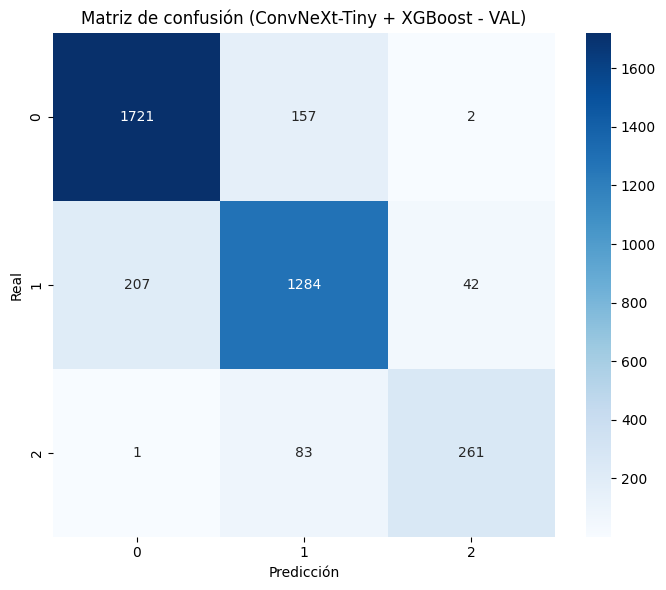

In [30]:
labels_sorted = sorted(int(x) for x in np.unique(y_val))
cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
)
plt.title("Matriz de confusión (ConvNeXt-Tiny + XGBoost - VAL)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### Importancia de características

En este modelo, las características corresponden a las 768 dimensiones del embedding de ConvNeXt-Tiny
más 22 features globales auxiliares (estadísticas de canal RGB + histograma en escala de grises).
La importancia se obtiene directamente del modelo XGBoost (ganancia promedio).

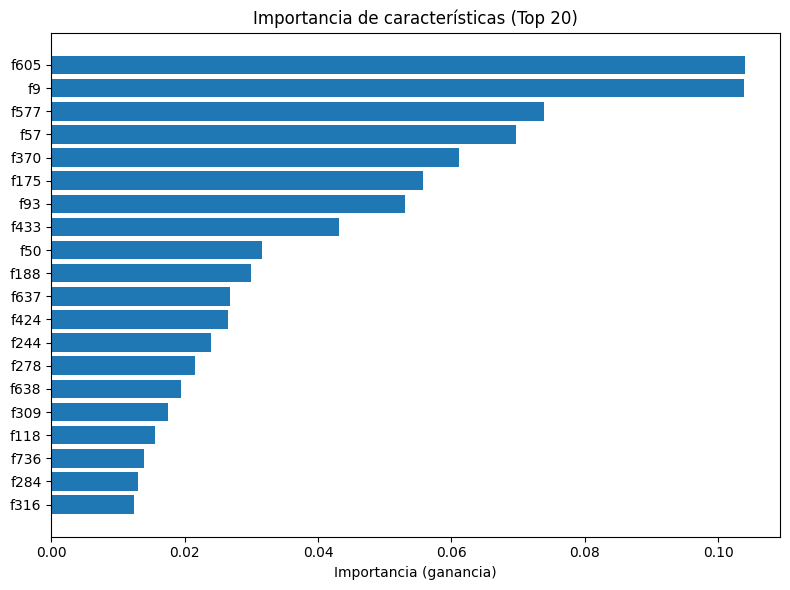

Top características por importancia (XGBoost):


,feature,importance
0,f605,0.104093
1,f9,0.103831
2,f577,0.073865
3,f57,0.069649
4,f370,0.061162
5,f175,0.055802
6,f93,0.053020
7,f433,0.043192
8,f50,0.031634
9,f188,0.029985


In [31]:
importances = xgb_best.feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": [f"f{i}" for i in range(len(importances))],
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_k = 20
top_df = importance_df.head(top_k)

plt.figure(figsize=(8, 6))
plt.barh(top_df["feature"][::-1], top_df["importance"][::-1])
plt.xlabel("Importancia (ganancia)")
plt.title(f"Importancia de características (Top {top_k})")
plt.tight_layout()
plt.show()

print("Top características por importancia (XGBoost):")
display(top_df)

Referencias:

- *Huang, G., Liu, Z., Van Der Maaten, L., & Weinberger, K. Q. (2017). Densely connected convolutional networks. In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 4700-4708).*
- *Kumar, V., Sharma, G., & Garg, D. (2023, November). Analysis of Early Detection and Prediction of Diabetic Retinopathy by Optimize Deep Learning with XG-Boosting. In Conference on Smart Generation Computing and Communication Networks (pp. 61-69). Cham: Springer Nature Switzerland.*
- *Nahiduzzaman, M., Islam, M. R., Goni, M. O. F., Anower, M. S., Ahsan, M., Haider, J., & Kowalski, M. (2023). Diabetic retinopathy identification using parallel convolutional neural network based feature extractor and ELM classifier. Expert Systems with Applications, 217, 119557.*
- *Nneji, G. U., Cai, J., Deng, J., Monday, H. N., Hossin, M. A., & Nahar, S. (2022). Identification of diabetic retinopathy using weighted fusion deep learning based on dual-channel fundus scans. Diagnostics, 12(2), 540.*
- *Meenakshi, K., Kishore, D., & Srinivasa Rao, C. (2024, October). Enhanced Detection of Diabetic Retinopathy Through Transfer Learning with DenseNet-121 and XGBoost Classifier. In International Conference on Computer & Communication Technologies (pp. 409-419). Singapore: Springer Nature Singapore.*
- *Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., y Plöd, M. (2023). CRISP-ML(Q). The ML Lifecycle Process. MLOps. INNOQ.*